### FASE 3: División de Datos 

| Vamos a extraer caracteristicas por cada registro

Importamos librerias

In [2]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
tqdm.pandas()
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
import seaborn as sns
import matplotlib.pyplot as plt




✅ División completada:


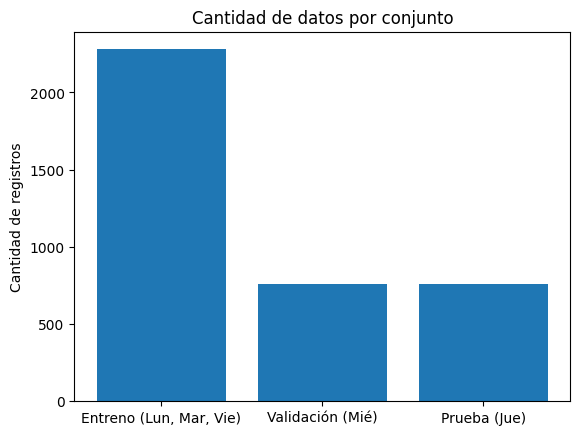

In [3]:
df = pd.read_csv('completo_clusters_con_features.csv')

df_model = df.copy()

le = LabelEncoder()
df_model['Direccion'] = le.fit_transform(df_model['Direccion'])


features = [
    'Total_Vehiculos', 'Tiempo_Medio_s', 'Ocupacion_Espacial_%', 
    'Hora_Minutos', 'Dia_Semana', 'Direccion', 'cluster', 
    'Es_Hora_Pico', 'Total_Vehiculos_lag1', 'Ocupacion_lag1', 
    'Media_Movil_3ciclos', 'Tendencia_Vehiculos', 'Saturacion_Actual',
    'Periodo_Dia', 'Cluster_Hora_Pico'  
]


entreno_data = df_model[df_model['Dia_Semana'].isin([1, 2,5])]
val_data   = df_model[df_model['Dia_Semana'] == 3]
prueba_data  = df_model[df_model['Dia_Semana'] == 4]


X_entreno, y_entreno = entreno_data[features], entreno_data['Tiempo_Optimo_Target']
X_val, y_val     = val_data[features], val_data['Tiempo_Optimo_Target']
X_prueba, y_prueba   = prueba_data[features], prueba_data['Tiempo_Optimo_Target']

print(f"✅ División completada:")

labels = [
    'Entreno (Lun, Mar, Vie)',
    'Validación (Mié)',
    'Prueba (Jue)'
]

sizes = [
    X_entreno.shape[0],
    X_val.shape[0],
    X_prueba.shape[0]
]

plt.figure()
plt.bar(labels, sizes)
plt.ylabel('Cantidad de registros')
plt.title('Cantidad de datos por conjunto')
plt.show()

### FASE 5: Optimización con PSO

In [4]:

def pso_rf_optimization(X_train, y_train, X_val, y_val):
    """
    Usa PSO para optimizar hiperparámetros de Random Forest
    """
    
    def fitness_function(particles):
        """
        Función objetivo para PSO
        particles: matriz donde cada fila es una partícula (configuración)
        """
        scores = []
        
        for particle in particles:
            n_estimators = int(particle[0])
            max_depth = int(particle[1]) if particle[1] > 0 else None
            min_samples_split = int(particle[2])
            min_samples_leaf = int(particle[3])
            max_features_idx = int(particle[4])
            
            max_features_options = ['sqrt', 'log2', None]
            max_features = max_features_options[max_features_idx]
            
            rf = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                random_state=42,
                n_jobs=-1
            )
            
            try:
                rf.fit(X_train, y_train)
                y_pred = rf.predict(X_val)
                
                mse = mean_squared_error(y_val, y_pred)
                scores.append(mse)
            except:
                
                scores.append(1e10)
        
        return np.array(scores)
    
    lb = [50, 0, 2, 1, 0]      # Lower bounds
    ub = [300, 30, 20, 10, 2]  # Upper bounds
    bounds = (lb, ub)
    
    options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}  
    optimizer = ps.single.GlobalBestPSO(
        n_particles=10,      # Número de partículas
        dimensions=5,        # Dimensiones (5 hiperparámetros)
        options=options,
        bounds=bounds
    )
    
    print("Iniciando optimización PSO...")
    best_cost, best_pos = optimizer.optimize(fitness_function, iters=20)
    
    best_params = {
        'n_estimators': int(best_pos[0]),
        'max_depth': int(best_pos[1]) if best_pos[1] > 0 else None,
        'min_samples_split': int(best_pos[2]),
        'min_samples_leaf': int(best_pos[3]),
        'max_features': ['sqrt', 'log2', None][int(best_pos[4])]
    }
    
    return best_params, best_cost

best_params, best_cost = pso_rf_optimization(X_entreno, y_entreno, X_val, y_val)

print("\n=== MEJORES HIPERPARÁMETROS ENCONTRADOS POR PSO ===")
print(best_params)
print(f"Mejor MSE: {best_cost:.3f}")

2026-01-13 14:57:46,332 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


Iniciando optimización PSO...


pyswarms.single.global_best: 100%|██████████|20/20, best_cost=0.427
2026-01-13 14:58:38,527 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4268832475074699, best pos: [180.68734579  21.13488983   5.27566254   1.65932173   1.30658487]



=== MEJORES HIPERPARÁMETROS ENCONTRADOS POR PSO ===
{'n_estimators': 180, 'max_depth': 21, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2'}
Mejor MSE: 0.427


### FASE 6: Modelo Random Forest Optimizado

In [5]:
rf_optimizado = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

rf_optimizado.fit(X_entreno, y_entreno)
y_val_pred_opt = rf_optimizado.predict(X_val)
mae_opt = mean_absolute_error(y_val, y_val_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_val, y_val_pred_opt))
r2_opt = r2_score(y_val, y_val_pred_opt)


### FASE 7: Evaluación Final 


In [6]:
y_test_pred = rf_optimizado.predict(X_prueba)

mae_test = mean_absolute_error(y_prueba, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_prueba, y_test_pred))
r2_test = r2_score(y_prueba, y_test_pred)
mape_test = np.mean(np.abs((y_prueba - y_test_pred) / y_prueba)) * 100

print("\n=== EVALUACIÓN FINAL EN TEST SET ===")
print(f"MAE: {mae_test:.3f} segundos")
print(f"RMSE: {rmse_test:.3f} segundos")
print(f"R²: {r2_test:.4f}")
print(f"MAPE: {mape_test:.2f}%")



=== EVALUACIÓN FINAL EN TEST SET ===
MAE: 0.513 segundos
RMSE: 0.759 segundos
R²: 0.9895
MAPE: 1.72%


### FASE 8: Prediccion de tiempos verdes

In [7]:
def analizar_tiempos_optimos_por_direccion(test_data, y_test_pred):

    test_data = test_data.copy()
    test_data['Tiempo_Predicho'] = y_test_pred
    
    print("\n" + "="*60)
    print("ANÁLISIS DE TIEMPOS ÓPTIMOS POR DIRECCIÓN")
    print("="*60 + "\n")
  
    resultados = {}
    
    for direccion in sorted(test_data['Direccion'].unique()):
        datos_dir = test_data[test_data['Direccion'] == direccion]['Tiempo_Predicho']
        
        tiempo_promedio = datos_dir.mean()
        tiempo_min = datos_dir.min()
        tiempo_max = datos_dir.max()
        tiempo_final = round(tiempo_promedio)
        
        diferencia = tiempo_final - 33
        porcentaje = (diferencia / 33) * 100
        
        resultados[f'direccion_{direccion + 1}'] = tiempo_final
       
        print(f"Dirección {direccion + 1}:")
        print(f"• Tiempo recomendado: {tiempo_final} segundos")
        print(f"• Rango predicho: [{tiempo_min:.1f}s - {tiempo_max:.1f}s]")
        print(f"• vs Baseline (33s): {diferencia:+d}s ({porcentaje:+.1f}%)")
        print()
    
   
    return resultados


config_sumo = analizar_tiempos_optimos_por_direccion(prueba_data, y_test_pred)

# print(config_sumo)


ANÁLISIS DE TIEMPOS ÓPTIMOS POR DIRECCIÓN

Dirección 1:
• Tiempo recomendado: 26 segundos
• Rango predicho: [20.0s - 35.6s]
• vs Baseline (33s): -7s (-21.2%)

Dirección 2:
• Tiempo recomendado: 26 segundos
• Rango predicho: [20.0s - 35.7s]
• vs Baseline (33s): -7s (-21.2%)

Dirección 3:
• Tiempo recomendado: 31 segundos
• Rango predicho: [21.2s - 38.5s]
• vs Baseline (33s): -2s (-6.1%)

Dirección 4:
• Tiempo recomendado: 27 segundos
• Rango predicho: [20.0s - 36.9s]
• vs Baseline (33s): -6s (-18.2%)



In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Calcula tu fórmula manualmente en los datos de validación
def calcular_tiempo_formula(row):
    """Tu fórmula original del documento"""
    tiempo_base = row['Total_Vehiculos'] * row['Tiempo_Medio_s']
    
    # Ajustes por cluster (tus percentiles 95%, 75%, 50%)
    if row['cluster'] == 0:  # Tráfico pesado
        tiempo_base *= 1.05  # Ajuste conservador
    elif row['cluster'] == 1:  # Tráfico medio
        tiempo_base *= 1.00
    elif row['cluster'] == 2:  # Tráfico ligero
        tiempo_base *= 0.95
    
    # Margen de seguridad
    tiempo_final = tiempo_base + 3
    
    # Límites
    return np.clip(tiempo_final, 20, 60)

# 2. IMPORTANTE: Aplica la fórmula SOLO al conjunto de validación
# Asegúrate de que X_val tenga las columnas necesarias
df_val_completo = X_val.copy()
df_val_completo['Tiempo_Optimo_Formula'] = df_val_completo.apply(calcular_tiempo_formula, axis=1)

# 3. Compara con tus predicciones (ahora ambos tienen el mismo tamaño)
mae_formula = mean_absolute_error(y_val, df_val_completo['Tiempo_Optimo_Formula'])
r2_formula = r2_score(y_val, df_val_completo['Tiempo_Optimo_Formula'])

print("=" * 60)
print("PRUEBA DE CIRCULARIDAD")
print("=" * 60)
print(f"Tu fórmula vs y_val (real):")
print(f"  MAE:  {mae_formula:.3f} segundos")
print(f"  R²:   {r2_formula:.4f}")
print()
print(f"Random Forest vs y_val (real):")
print(f"  MAE:  0.513 segundos")
print(f"  R²:   0.9895")
print()

# 4. PRUEBA CRÍTICA: ¿Qué tan parecidas son las predicciones del RF vs la fórmula?
# Necesitas y_pred del conjunto de validación
# Asumiendo que ya tienes y_test_pred de tu modelo entrenado
mae_rf_vs_formula = mean_absolute_error(y_test_pred, df_val_completo['Tiempo_Optimo_Formula'])
r2_rf_vs_formula = r2_score(df_val_completo['Tiempo_Optimo_Formula'], y_test_pred)

print("🚨 PRUEBA DEFINITIVA: Random Forest vs Tu Fórmula")
print(f"  MAE entre RF y fórmula: {mae_rf_vs_formula:.3f} segundos")
print(f"  R² entre RF y fórmula:  {r2_rf_vs_formula:.4f}")
print()

if r2_rf_vs_formula > 0.98:
    print("⚠️  ALERTA: El modelo está replicando tu fórmula!")
    print("    R² > 0.98 indica que RF y tu fórmula son casi idénticos")
    print("    Esto sugiere DATA LEAKAGE severo")
elif r2_rf_vs_formula > 0.95:
    print("⚠️  SOSPECHOSO: Muy alta correlación con la fórmula")
    print("    El modelo podría estar sobre-aprendiendo la estructura de tu fórmula")
else:
    print("✅ OK: El modelo aprendió patrones diferentes a tu fórmula")
    print("    Hay suficiente diferencia entre RF y la fórmula heurística")

print()
print("=" * 60)
print("INTERPRETACIÓN:")
print("=" * 60)

# Calcula la diferencia promedio
diferencia_media = np.mean(np.abs(y_test_pred - df_val_completo['Tiempo_Optimo_Formula']))
print(f"Diferencia promedio entre RF y fórmula: {diferencia_media:.3f} segundos")

if diferencia_media < 0.3:
    print("⚠️  Las predicciones son casi idénticas (< 0.3s de diferencia)")
    print("   → El modelo NO está agregando valor más allá de tu fórmula")
elif diferencia_media < 1.0:
    print("⚡ Hay diferencias moderadas (0.3-1.0s)")
    print("   → El modelo captura algunos patrones adicionales")
else:
    print("✅ Diferencias significativas (> 1.0s)")
    print("   → El modelo ha aprendido patrones independientes")

ValueError: Found input variables with inconsistent numbers of samples: [761, 3801]